In [2]:
import matplotlib.pyplot as plt

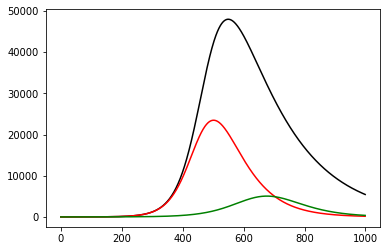

In [21]:
class SIR:
    
    def __init__(self, tasa_contagio, tasa_recuperacion, tasa_fallecimiento):
        self.tasa_contagio = tasa_contagio
        self.tasa_recuperacion = tasa_recuperacion
        self.tasa_fallecimiento = tasa_fallecimiento
        
    def run(self, tmax=100, fmt='-k'):
        
        poblacion = 100000.
        
        casos_totales = [0] * tmax
        casos_fallecidos = [0] * tmax
        casos_recuperados = [0] * tmax
        casos_activos = [0] * tmax
        susceptibles = [0] * tmax
        
        nuevos_activos = [0] * tmax
        nuevos_fallecidos = [0] * tmax
        nuevos_recuperados = [0] * tmax
        
        casos_totales[0] = 1
        casos_activos[0] = 1
        susceptibles[0] = poblacion - 1
        
        nuevos_activos[0] = 1
        
        for t in range(1, tmax):
            
            nuevos_activos[t] = casos_activos[t-1] * self.tasa_contagio * susceptibles[t-1] / poblacion
            nuevos_recuperados[t] = casos_activos[t-1] * self.tasa_recuperacion
            nuevos_fallecidos[t] = casos_activos[t-1] * self.tasa_fallecimiento
            
            susceptibles[t] = susceptibles[t-1] - nuevos_activos[t]
            
            casos_totales[t] = casos_totales[t-1] + nuevos_activos[t]
            casos_fallecidos[t] = casos_fallecidos[t-1] + nuevos_fallecidos[t]
            casos_recuperados[t] = casos_recuperados[t-1] + nuevos_recuperados[t-1]
            
            casos_activos[t] = casos_activos[t-1] + nuevos_activos[t] - nuevos_recuperados[t]  - nuevos_fallecidos[t]
            
        
        plt.plot(casos_activos, fmt)
            
            
m0 = SIR(tasa_contagio = 0.03, tasa_recuperacion=0.005, tasa_fallecimiento = 0.001)
m1 = SIR(tasa_contagio = 0.04, tasa_recuperacion=0.015, tasa_fallecimiento = 0.001)
m2 = SIR(tasa_contagio = 0.05, tasa_recuperacion=0.025, tasa_fallecimiento = 0.01)

m0.run(1000, fmt='-k')
m1.run(1000, fmt='-r')
m2.run(1000, fmt='-g')